# Level 1 — Single-Nucleus Census of an Adult Glioblastoma

## CAJAL "Neuromics 2026" — Computational Mini-Project C10 (Level 1)

**Estimated time:** ~2 days

**Learning objectives**
- Load and explore single-nucleus RNA-seq (snRNA-seq) data in the AnnData format
- Perform quality control on nuclei and understand what has *already* been done to the data
- Normalize, select features, and integrate across donors (Harmony **and** scVI, compared)
- Cluster and annotate broad cell types using marker genes **and** an automated classifier
- Separate malignant cells from the non-malignant tumour microenvironment (TME) using copy-number inference
- Characterise a continuous **malignant cell-state axis** and how it varies between donors

**Dataset:** snRNA-seq (10x Multiome, RNA modality) from **two adult patients** with high-grade glioma — donors `AT10` and `AT14`, sampled from several tissue sites each. `~118,000` nuclei × `~36,600` genes. The expression matrix holds **raw integer UMI counts**.

> **We are not telling you where this data comes from yet.** There is no paper, title, or figure to look up. Your job is to let the data speak: reconstruct the cell types and tumour states yourself, the way the original analysts had to. The "reveal" happens in Level 2.

---

## 0. Setup

In [1]:
import scanpy as sc

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project's shared helper package importable.
sys.path.insert(0, "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/src")
import gbmspace_utils as gu
from gbmspace_utils.analysis import (
    MALIGNANT_AXIS_MARKERS, MAJOR_CLASS_OF, TME_MARKERS, EMT_MARKERS,
    score_axis, assign_dominant_state,
)

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(5, 4))
%matplotlib inline

print("scanpy", sc.__version__, "| anndata", ad.__version__)

scanpy 1.11.5 | anndata 0.12.18


/tmp/slurm_tp185005_452599.tmp/ipykernel_2314630/3667792579.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__, "| anndata", ad.__version__)
/tmp/slurm_tp185005_452599.tmp/ipykernel_2314630/3667792579.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("scanpy", sc.__version__, "| anndata", ad.__version__)


## 1. Load and explore the data

🔬 **TASK 1.1:** Load the snRNA-seq dataset and inspect the AnnData object — shape, `.obs` columns, and confirm what is stored in `.X`.

In [3]:
DATA = "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/data/snRNA_seq/level1_prepared/gbm_l1_snrna_AT10_AT14_raw.h5ad"
adata = sc.read_h5ad(DATA)
print(adata)
print(f"\nShape: {adata.n_obs:,} nuclei x {adata.n_vars:,} genes")
print(f"\n.obs columns: {list(adata.obs.columns)}")

AnnData object with n_obs × n_vars = 118471 × 36601
    obs: 'cell_id', 'donor_id', 'site_id', 'sample', 'n_genes_by_counts', 'total_counts', 'mt_frac', 'doublet_scores'

Shape: 118,471 nuclei x 36,601 genes

.obs columns: ['cell_id', 'donor_id', 'site_id', 'sample', 'n_genes_by_counts', 'total_counts', 'mt_frac', 'doublet_scores']


In [4]:
# Per-donor and per-site breakdown
print("Nuclei per donor:")
print(adata.obs["donor_id"].value_counts())
print("\nNuclei per tissue site:")
print(adata.obs["site_id"].value_counts())

Nuclei per donor:
donor_id
AT10    85983
AT14    32488
Name: count, dtype: int64

Nuclei per tissue site:
site_id
AT10-BRA-5-FO-1    29242
AT10-BRA-5-FO-4    26034
AT14-BRA-4-FO-2    20323
AT10-BRA-5-FO-2    18184
AT10-BRA-5-FO-3    12523
AT14-BRA-4-FO-4    12165
Name: count, dtype: int64


🔬 **TASK 1.2:** Confirm that `.X` holds raw integer counts — every downstream choice (normalization, `seurat_v3` HVGs, scVI, CNV inference) depends on this.

In [5]:
X_sample = adata.X[:500].toarray()
print("min:", X_sample.min(), "| max:", X_sample.max())
print("all integer-valued?:", np.allclose(X_sample, np.round(X_sample)))
print("sparse format:", type(adata.X).__name__, "| dtype:", adata.X.dtype)
# A pre-existing .raw is present and currently just duplicates these raw counts.
print("\n.raw present:", adata.raw is not None, "| .raw shape:",
      adata.raw.shape if adata.raw is not None else None)

min: 0.0 | max: 2826.0
all integer-valued?: True
sparse format: csr_matrix | dtype: float32

.raw present: True | .raw shape: (118471, 36601)


❓ **QUESTION:** The two donors contribute very different nuclei counts (`AT10` ≈ 86k vs `AT14` ≈ 32k), and each donor was sampled from several physical tissue sites. Why might naively pooling all nuclei and clustering immediately be a problem — and which `.obs` column is the natural *batch* variable to correct for later?

## 2. Quality control

Not every nuclear barcode is a good nucleus: some are empty/ambient, some are doublets (two nuclei in one droplet), some are stressed. The three workhorse single-cell QC metrics are:

| Metric | Low values suggest | High values suggest |
|---|---|---|
| total counts (UMIs) per nucleus | empty droplet / debris | doublet |
| genes detected per nucleus | low-complexity / empty | doublet |
| % mitochondrial counts | (in nuclei, mito is expected *low*) | cytoplasmic leakage / stress |

In human data, mitochondrial genes start with `MT-`. We also have a precomputed Scrublet **doublet score** per nucleus in `.obs['doublet_scores']`.

🔬 **TASK 2.1:** Flag mitochondrial genes and compute QC metrics with `sc.pp.calculate_qc_metrics`.

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
print(f"Mitochondrial genes flagged: {int(adata.var['mt'].sum())}")
print("\nQC summary (whole dataset):")
print(adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt", "doublet_scores"]]
      .describe().round(2))

Mitochondrial genes flagged: 13

QC summary (whole dataset):
       total_counts  n_genes_by_counts  pct_counts_mt  doublet_scores
count     118471.00          118471.00      118471.00       118471.00
mean        4452.02            2204.54           1.35            0.07
std         3750.39            1104.29           1.58            0.05
min         1001.00             516.00           0.00            0.00
25%         2323.00            1447.00           0.29            0.03
50%         3482.00            1966.00           0.80            0.05
75%         5202.00            2651.00           1.80            0.09
max        73000.00           12246.00           9.99            0.35


🔬 **TASK 2.2:** Visualise the QC distributions, split by donor, and look at the joint counts-vs-genes structure.

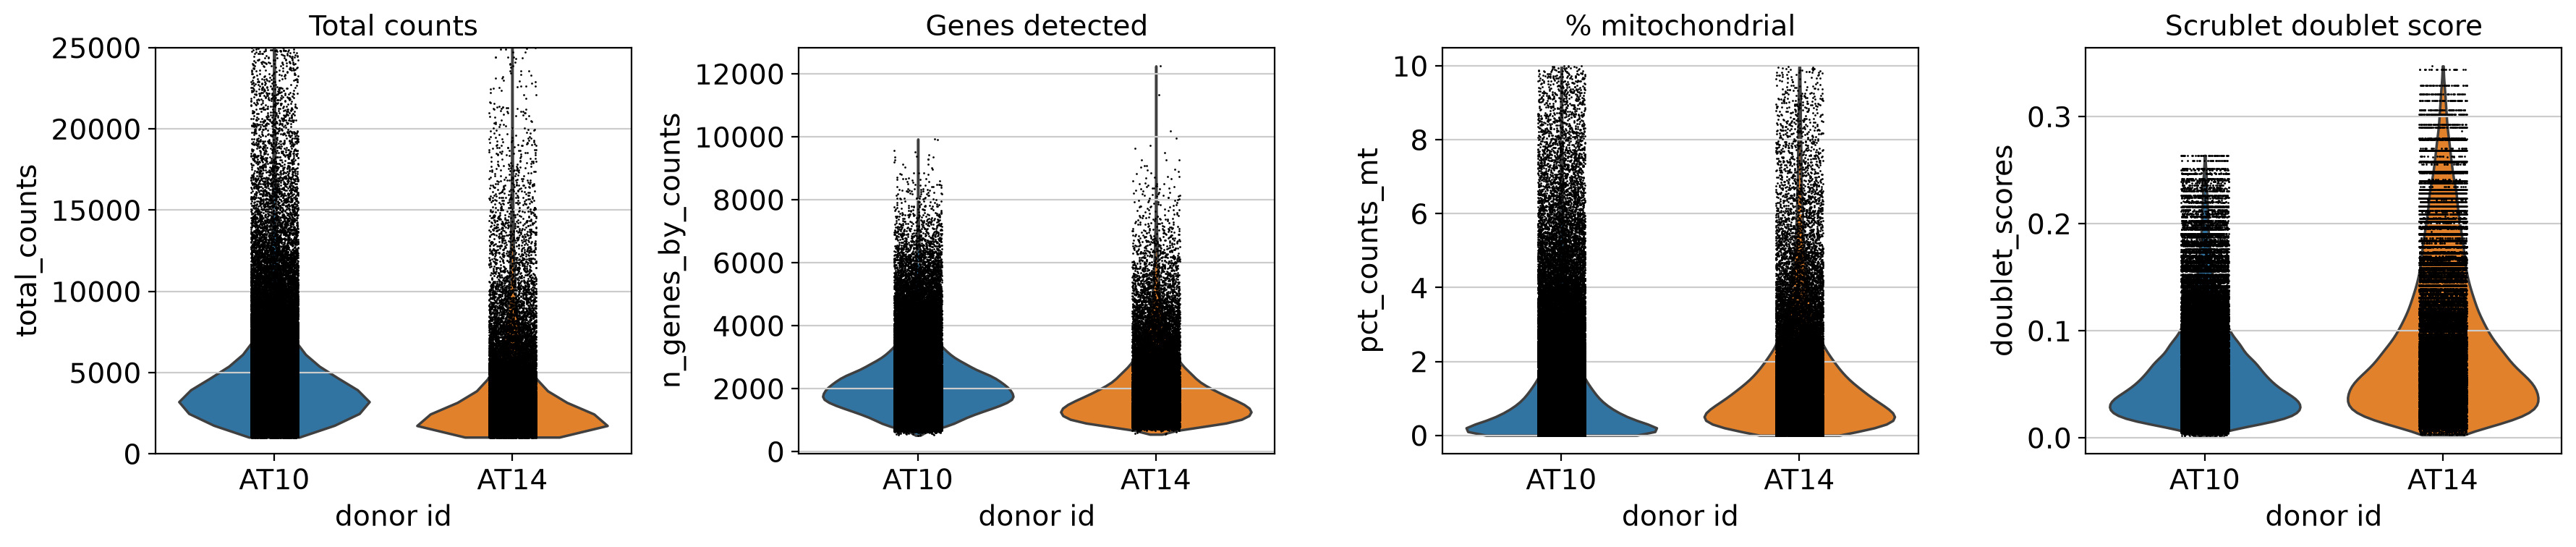

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sc.pl.violin(adata, "total_counts", groupby="donor_id", ax=axes[0], show=False)
axes[0].set_title("Total counts"); axes[0].set_ylim(0, 25000)
sc.pl.violin(adata, "n_genes_by_counts", groupby="donor_id", ax=axes[1], show=False)
axes[1].set_title("Genes detected")
sc.pl.violin(adata, "pct_counts_mt", groupby="donor_id", ax=axes[2], show=False)
axes[2].set_title("% mitochondrial")
sc.pl.violin(adata, "doublet_scores", groupby="donor_id", ax=axes[3], show=False)
axes[3].set_title("Scrublet doublet score")
plt.tight_layout(); plt.show()

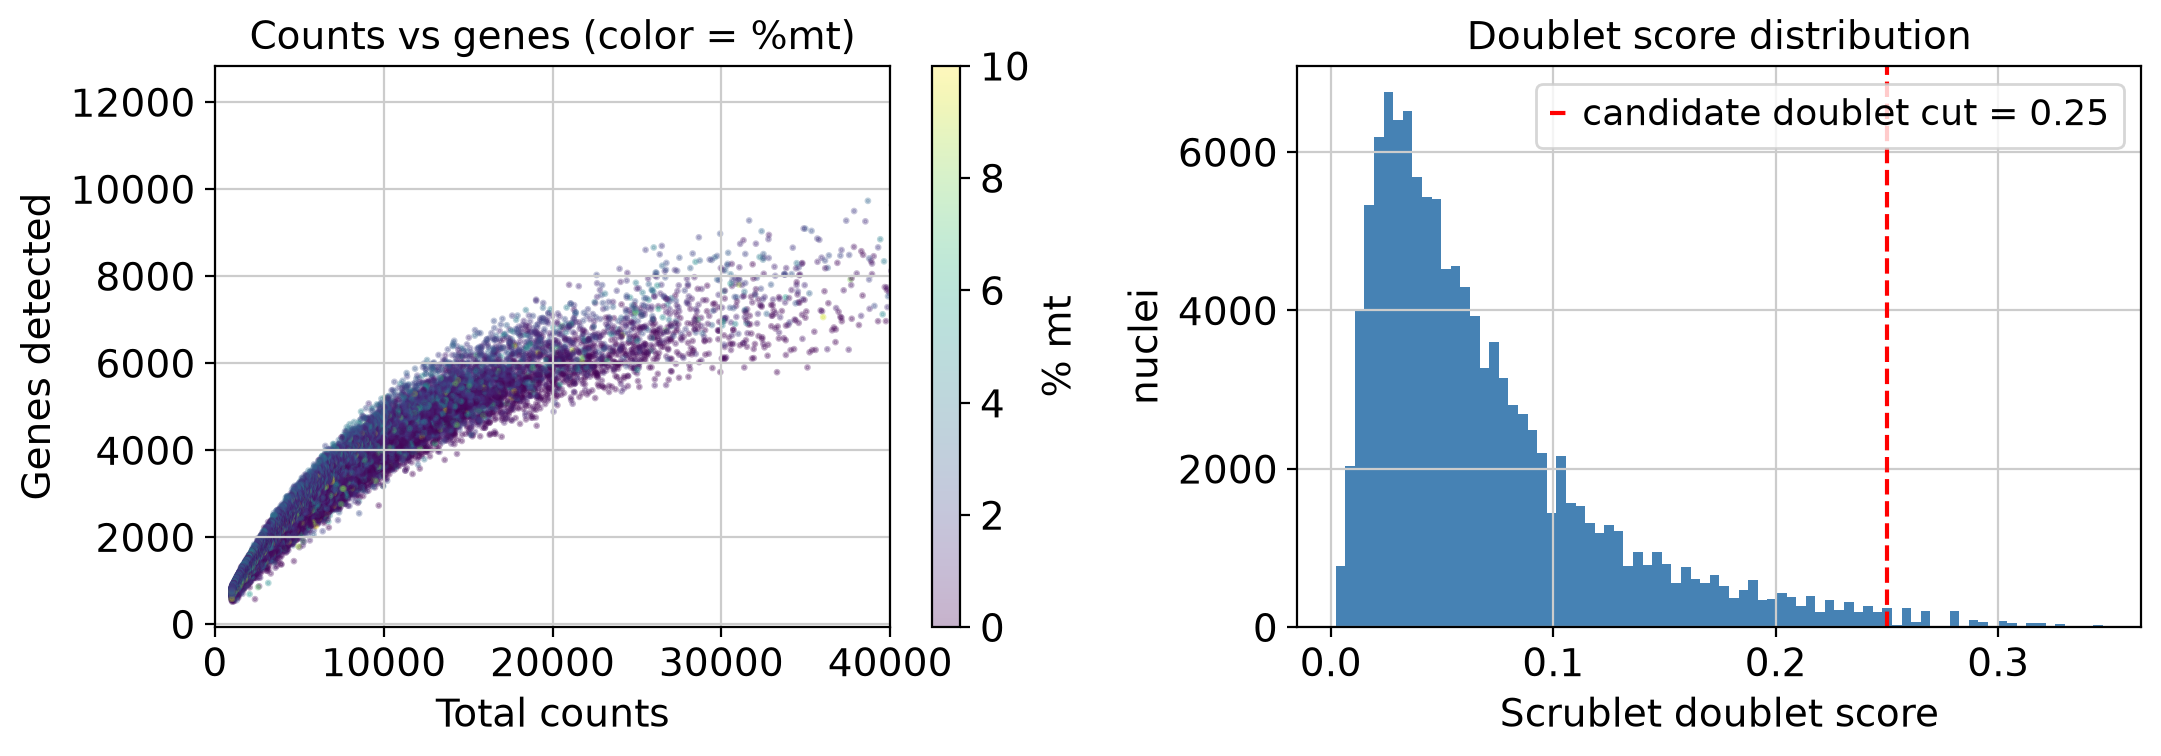

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sca = axes[0].scatter(adata.obs["total_counts"], adata.obs["n_genes_by_counts"],
                      c=adata.obs["pct_counts_mt"], cmap="viridis", s=2, alpha=0.3, vmax=10)
axes[0].set(xlabel="Total counts", ylabel="Genes detected",
            title="Counts vs genes (color = %mt)", xlim=(0, 40000))
fig.colorbar(sca, ax=axes[0], label="% mt")
axes[1].hist(adata.obs["doublet_scores"], bins=80, color="steelblue")
axes[1].axvline(0.25, color="red", ls="--", label="candidate doublet cut = 0.25")
axes[1].set(xlabel="Scrublet doublet score", ylabel="nuclei", title="Doublet score distribution")
axes[1].legend()
plt.tight_layout(); plt.show()

🔬 **TASK 2.3:** Look at the *floors* of these distributions before choosing thresholds. A standard nuclei-QC recipe removes nuclei with `< ~500` genes, `< ~1000` UMIs, or `> 10%` mito. Check how many nuclei those cuts would actually remove here.

In [9]:
print("Hard minima/maxima already present in the data:")
print(f"  min total_counts      = {adata.obs['total_counts'].min():.0f}")
print(f"  min n_genes_by_counts = {adata.obs['n_genes_by_counts'].min():.0f}")
print(f"  max pct_counts_mt     = {adata.obs['pct_counts_mt'].max():.2f} %")

standard = ((adata.obs['n_genes_by_counts'] >= 500) &
            (adata.obs['total_counts'] >= 1000) &
            (adata.obs['pct_counts_mt'] <= 10))
print(f"\nNuclei failing the standard genes/UMI/mito cuts: {int((~standard).sum())} "
      f"out of {adata.n_obs}")

Hard minima/maxima already present in the data:
  min total_counts      = 1001
  min n_genes_by_counts = 516
  max pct_counts_mt     = 9.99 %

Nuclei failing the standard genes/UMI/mito cuts: 0 out of 118471


💡 **HINT:** Notice the floors — `total_counts` bottoms out right at ~1000, `n_genes_by_counts` at ~500, and `pct_counts_mt` never exceeds ~10%. That is not a coincidence: **basic per-nucleus QC has already been applied to this dataset**, so the genes/UMI/mito filters remove essentially nothing. That is realistic — you are often handed data that has had a first QC pass. The QC lever that is still meaningful here is **doublet removal**, which has *not* been applied.

🔬 **TASK 2.4:** Apply QC. Keep the standard cuts as explicit guardrails (so the notebook is correct even on un-filtered data), and add a Scrublet doublet cut at `0.25` (the upper tail in the histogram above). Then drop genes seen in `< 3` nuclei. Report nuclei remaining.

In [10]:
adata[adata.obs["donor_id"] == "AT14"]

View of AnnData object with n_obs × n_vars = 32488 × 36601
    obs: 'cell_id', 'donor_id', 'site_id', 'sample', 'n_genes_by_counts', 'total_counts', 'mt_frac', 'doublet_scores', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'donor_id_colors'

In [11]:
n0 = adata.n_obs

# Standard guardrails (no-ops on this already-filtered data, but correct in general):
adata = adata[(adata.obs["n_genes_by_counts"] >= 500) &
              (adata.obs["total_counts"] >= 1000) &
              (adata.obs["pct_counts_mt"] <= 10)].copy()
n_after_std = adata.n_obs

# The meaningful filter for THIS data — putative doublets:
adata = adata[adata.obs["doublet_scores"] < 0.25].copy()
n_after_dbl = adata.n_obs

sc.pp.filter_genes(adata, min_cells=3)

print(f"Start:                 {n0:,} nuclei")
print(f"After standard cuts:   {n_after_std:,}  (removed {n0 - n_after_std})")
print(f"After doublet < 0.25:  {n_after_dbl:,}  (removed {n_after_std - n_after_dbl})")
print(f"Genes after min_cells=3: {adata.n_vars:,}")
print(f"\nNuclei per donor now:\n{adata.obs['donor_id'].value_counts()}")

Start:                 118,471 nuclei
After standard cuts:   118,471  (removed 0)
After doublet < 0.25:  117,200  (removed 1271)
Genes after min_cells=3: 33,923

Nuclei per donor now:
donor_id
AT10    85854
AT14    31346
Name: count, dtype: int64


⚠️ **CHECKPOINT:** You should have roughly **116,000–118,000 nuclei** remaining (the doublet cut removes ~1,000–1,500; the genes/UMI/mito cuts remove ~0 because the data was pre-filtered). After the `min_cells=3` gene filter you should keep on the order of **33,000–34,000 genes**. If you lost tens of thousands of nuclei, your thresholds are far too strict for *this* dataset — re-read the floors above.

## 3. Normalization and feature selection

Raw counts conflate biology with sequencing depth. We library-size-normalize, log-transform, snapshot the result into `.raw` (for marker plotting later), then select highly variable genes (HVGs).

🔬 **TASK 3.1:** Stash raw counts in a layer, then `normalize_total` (target 1e4) + `log1p`, and freeze `.raw`.

In [12]:
# Keep raw counts available for seurat_v3 HVGs, scVI, and CNV inference.
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Snapshot the normalized, all-genes matrix. This intentionally OVERWRITES the pre-existing
# .raw (which only duplicated the raw counts) with the post-normalization state used for
# marker dotplots / score_genes downstream.
adata.raw = adata

c0 = adata.layers["counts"][0].toarray().ravel()
n0 = adata.X[0].toarray().ravel()
print(f"cell 0, first nonzero gene -> raw={c0[c0>0][0]:.0f}, normalized+log={n0[c0>0][0]:.3f}")

cell 0, first nonzero gene -> raw=1, normalized+log=0.128


🔬 **TASK 3.2:** Select ~3000 HVGs with `flavor="seurat_v3"` on the **raw counts layer** (this flavor models mean–variance on counts, not log data), computed per-donor (`batch_key`) so donor-specific genes don't dominate.

HVGs selected: 3000


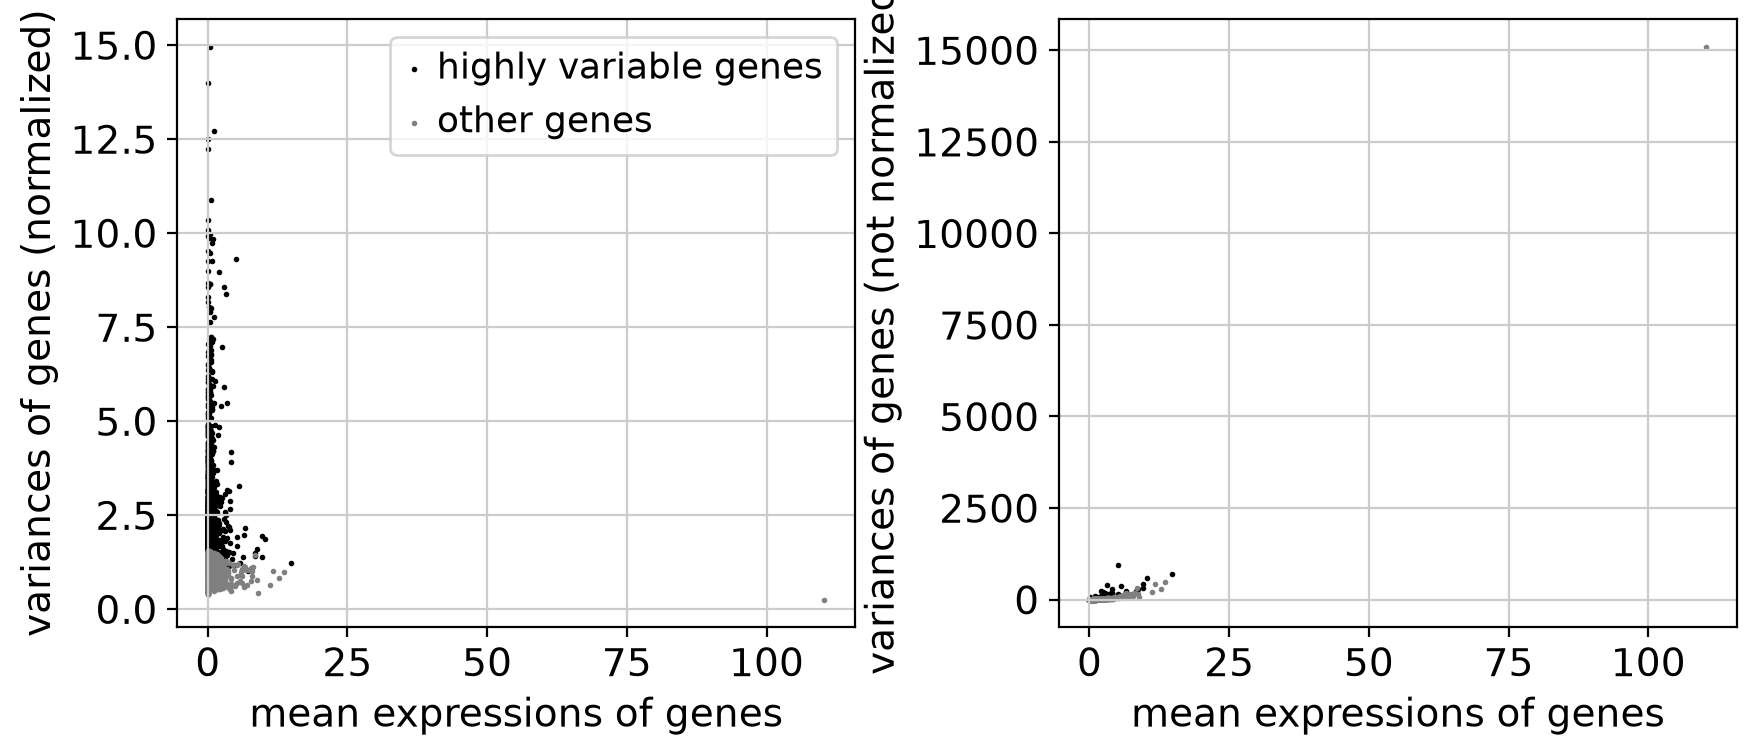

In [13]:
sc.pp.highly_variable_genes(
    adata, n_top_genes=3000, flavor="seurat_v3", layer="counts", batch_key="donor_id",
)
print(f"HVGs selected: {int(adata.var['highly_variable'].sum())}")
sc.pl.highly_variable_genes(adata)

❓ **QUESTION:** Why do we run `seurat_v3` HVG selection on the *raw counts* layer rather than on the log-normalized matrix? And why pass `batch_key="donor_id"` — what failure mode does that guard against?

## 4. Dimensionality reduction and **donor integration**

We have two donors. If donor identity drives the top axes of variation, clusters will split by patient instead of by biology. We will:
1. scale HVGs → PCA (the uncorrected embedding),
2. run **two** integration methods over PCA/counts keyed on `donor_id` — **Harmony** and **scVI** — and compare them,
3. pick one to carry downstream via an `INTEGRATION_METHOD` flag, keeping *both* embeddings in `.obsm` so the flag works either way.

🔬 **TASK 4.1:** Scale HVGs, run PCA (50 comps), inspect the variance elbow.

In [ ]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50)

# Carry the PCA back onto the full object (this is the *uncorrected* embedding).
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.uns["pca"] = adata_hvg.uns["pca"]

sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


💡 **HINT:** The elbow flattens by ~30 PCs; we use 30 for neighbor graphs throughout. First let's *see* the donor (batch) effect in the uncorrected space.

In [ ]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, key_added="neighbors_uncorr")
sc.tl.umap(adata, neighbors_key="neighbors_uncorr")
adata.obsm["X_umap_uncorr"] = adata.obsm["X_umap"].copy()

sc.pl.embedding(adata, "X_umap_uncorr", color="donor_id", title="Uncorrected (PCA) — colored by donor")

🔬 **TASK 4.2 — Harmony.** Integrate the PCA embedding on `donor_id`. (We call `harmonypy` directly and reshape its output ourselves: the installed `harmonypy`/`scanpy` combination returns `Z_corr` in a shape that the thin `sc.external.pp.harmony_integrate` wrapper mishandles — a good reminder that library version mismatches are a normal part of real analysis.)

In [ ]:
sc.pl.umap(adata, color=["donor_id", "doublet_scores"])

In [ ]:
adata

In [ ]:
import harmonypy
import time

t0 = time.time()
ho = harmonypy.run_harmony(adata.obsm["X_pca"], adata.obs, ["donor_id"], max_iter_harmony=20)
# Z_corr is (n_pcs x n_cells); transpose to (n_cells x n_pcs). np.asarray guards the
# version-specific return type.
Z = np.asarray(ho.Z_corr)
if Z.shape[0] != adata.n_obs:
    Z = Z.T
adata.obsm["X_pca_harmony"] = Z
print(f"Harmony done in {time.time()-t0:.1f}s -> X_pca_harmony {adata.obsm['X_pca_harmony'].shape}")

🔬 **TASK 4.3 - scVI.** scVI is a deep generative model trained on raw counts. By default you **load** a GPU-trained latent (fast). Set `TRAIN_SCVI = True` to train scVI on **your own cells** instead (uses a GPU if available; a few minutes on CPU). Either way it fills `adata.obsm['X_scvi']` for your cells, so the comparison below works the same.

In [ ]:
# [KEEP-IN-STUDENT]
# scVI is a GPU-scale step. The FULL 117k-cell latent was trained on a GPU and saved -- it is
# loaded below and used for the comparison and any downstream scVI. Set TRAIN_SCVI = True to also
# run scVI YOURSELF as a quick proof-of-concept on a CPU-friendly subsample (no GPU needed).
import os
TRAIN_SCVI = False
SCVI_LATENT_FILE = "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/precomputed/level1_scvi_latent.npz"

💡 **HINT — runtime caveat.** scVI training cost scales with dataset size and is genuinely slow on CPU for tens of thousands of cells — avoid scvi-tools' automatic epoch heuristic (`get_max_epochs_heuristic`) for a teaching session; in this environment it picked an epoch count that made the full run take well over an hour with no early feedback, which is the wrong trade for a live class. Use a small, **fixed** epoch count instead — you always know your runtime budget up front. Raise it if you have time or GPU access.

In [ ]:
# [KEEP-IN-STUDENT]
SCVI_MAX_EPOCHS = 20   # fixed epochs: a few minutes on CPU for the full set, seconds on a GPU

if TRAIN_SCVI:
    # Train scVI on YOUR cells and use that latent. Trains on the HVGs for speed; accelerator="auto"
    # uses a GPU if one is present, otherwise CPU (a few minutes for the full set).
    import scvi, torch, time
    torch.set_num_threads(8); scvi.settings.seed = 0
    _genes = adata.var_names[adata.var["highly_variable"]] if "highly_variable" in adata.var.columns else adata.var_names
    scvi_ad = adata[:, _genes].copy()
    scvi.model.SCVI.setup_anndata(scvi_ad, layer="counts", batch_key="donor_id")
    _m = scvi.model.SCVI(scvi_ad, n_latent=30)
    _t0 = time.time()
    _m.train(max_epochs=SCVI_MAX_EPOCHS, accelerator="auto", early_stopping=False)
    adata.obsm["X_scvi"] = _m.get_latent_representation()
    print(f"Trained scVI on your {adata.n_obs:,} cells ({SCVI_MAX_EPOCHS} epochs) in "
          f"{(time.time()-_t0)/60:.1f} min -> X_scvi {adata.obsm['X_scvi'].shape}")
else:
    # Load the precomputed (GPU-trained) latent and use it for exactly YOUR cells.
    if not os.path.exists(SCVI_LATENT_FILE):
        raise FileNotFoundError(
            f"Precomputed scVI latent not found:\n  {SCVI_LATENT_FILE}\n"
            "Repoint this path (see CLAUDE.md), or set TRAIN_SCVI=True to train it yourself.")
    _d = np.load(SCVI_LATENT_FILE, allow_pickle=True)
    _lat = pd.DataFrame(_d["latent"], index=_d["obs_names"].astype(str))
    _missing = adata.obs_names.difference(_lat.index)
    if len(_missing):
        raise ValueError(
            f"{len(_missing):,} of your {adata.n_obs:,} cells are not in the precomputed scVI latent. "
            "The precomputed latent covers the reference cell set, so your QC must keep a SUBSET of it "
            "(filter more, but do not add cells the reference dropped). Re-check QC, or set "
            "TRAIN_SCVI=True to train scVI on your own cells.")
    adata.obsm["X_scvi"] = _lat.reindex(adata.obs_names).values.astype("float32")
    print(f"Set X_scvi for your {adata.n_obs:,} cells from the precomputed latent -> {adata.obsm['X_scvi'].shape}.")
print("X_scvi shape:", adata.obsm["X_scvi"].shape)

🔬 **TASK 4.4 — compare integrations.** Build a neighbor graph + UMAP for each embedding and inspect donor mixing visually. Then quantify mixing with a simple **neighbor-purity** proxy: for each nucleus, the fraction of its k nearest neighbors from the *same* donor. Under perfect mixing this approaches each donor's global fraction; under no correction it approaches 1.0.

In [ ]:
# UMAPs for each integration
for basis, key in [("X_pca_harmony", "umap_harmony"), ("X_scvi", "umap_scvi")]:
    sc.pp.neighbors(adata, n_neighbors=15, use_rep=basis, key_added=f"nn_{key}")
    sc.tl.umap(adata, neighbors_key=f"nn_{key}")
    adata.obsm[f"X_{key}"] = adata.obsm["X_umap"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.embedding(adata, "X_umap_uncorr",  color="donor_id", ax=axes[0], show=False, title="Uncorrected")
sc.pl.embedding(adata, "X_umap_harmony", color="donor_id", ax=axes[1], show=False, title="Harmony")
sc.pl.embedding(adata, "X_umap_scvi",    color="donor_id", ax=axes[2], show=False, title="scVI")
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors

def same_donor_neighbor_fraction(emb, labels, k=30):
    nn = NearestNeighbors(n_neighbors=k + 1).fit(emb)
    idx = nn.kneighbors(emb, return_distance=False)[:, 1:]  # drop self
    lab = labels.to_numpy()
    same = (lab[idx] == lab[:, None]).mean(axis=1)
    return same

ideal = (adata.obs["donor_id"].value_counts(normalize=True) ** 2).sum()  # expected under perfect mixing
print(f"Expected same-donor neighbor fraction under perfect mixing: {ideal:.3f}\n")
for name, basis in [("Uncorrected", "X_pca"), ("Harmony", "X_pca_harmony"), ("scVI", "X_scvi")]:
    frac = same_donor_neighbor_fraction(adata.obsm[basis], adata.obs["donor_id"]).mean()
    print(f"  {name:12s}: mean same-donor neighbor fraction = {frac:.3f}")



💡 **HINT:** Both methods pull the mean same-donor neighbor fraction down from the uncorrected value toward the perfect-mixing baseline. For this two-donor teaching run we proceed with **Harmony**: it integrated in seconds (vs minutes for scVI on CPU), gives comparable mixing, and operates on the same interpretable PCA space. We keep `X_scvi` in `.obsm` so you can flip the flag and reproduce everything downstream with scVI instead.

🔬 **TASK 4.5:** Set the integration flag and build the **canonical** neighbor graph + UMAP that all downstream steps use.

In [ ]:
INTEGRATION_METHOD = "harmony"   # students: set to "harmony" or "scvi"
REP = {"harmony": "X_pca_harmony", "scvi": "X_scvi"}[INTEGRATION_METHOD]
print(f"Downstream embedding: {INTEGRATION_METHOD}  ({REP})")

sc.pp.neighbors(adata, n_neighbors=15, use_rep=REP)   # default key 'neighbors'
sc.tl.umap(adata)                                      # default key 'X_umap'
print("Canonical UMAP + neighbor graph built on", REP)

## 5. Clustering

Leiden community detection on the integrated neighbor graph. We sweep a few resolutions and pick one whose granularity is sensible for broad cell typing.

🔬 **TASK 5.1:** Run Leiden at resolutions 0.3 / 0.5 / 1.0 and compare cluster counts and UMAPs.

In [ ]:
for res in [0.3, 0.5, 1.0]:
    sc.tl.leiden(adata, resolution=res, key_added=f"leiden_r{res}",
                 flavor="igraph", n_iterations=2, directed=False)
    print(f"resolution {res}: {adata.obs[f'leiden_r{res}'].nunique()} clusters")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res in zip(axes, [0.3, 0.5, 1.0]):
    sc.pl.umap(adata, color=f"leiden_r{res}", ax=ax, show=False,
               title=f"Leiden res={res}", legend_loc="on data", legend_fontsize=7)
plt.tight_layout(); plt.show()

💡 **HINT:** We adopt **resolution 1.0** as the working clustering. Broad cell typing plus a malignant-state axis needs enough granularity to separate (a) the major TME lineages from malignant cells and (b) distinct malignant programs, without shattering into dozens of micro-clusters. Lower resolutions merged biologically distinct populations in this dataset.

In [ ]:
adata.obs["leiden"] = adata.obs["leiden_r1.0"]
print("Working clusters (res=1.0):", adata.obs["leiden"].nunique())
print(adata.obs["leiden"].value_counts().sort_index())

🔬 **TASK 5.2:** Check each cluster's donor composition — this distinguishes shared biology (both donors) from donor-private populations.

In [ ]:
comp = pd.crosstab(adata.obs["leiden"], adata.obs["donor_id"], normalize="index")
fig, ax = plt.subplots(figsize=(10, 4))
comp.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", width=0.9)
ax.set(xlabel="Leiden cluster", ylabel="donor fraction", title="Donor composition per cluster")
ax.legend(title="donor", bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()

## 6. Broad cell-type annotation

We assign each cluster a coarse cell-type label using **two independent lines of evidence**, then reconcile them:
1. **Marker genes** — a curated TME/lineage panel (`gbmspace_utils.TME_MARKERS`), via dotplot and per-cluster gene scores.
2. **CellTypist** — an automated reference classifier; we use the `Developing_Human_Brain` model (a developmental-brain reference, appropriate for glioma whose malignant cells mimic neurodevelopmental programs).

🔬 **TASK 6.1:** Rank marker genes per cluster (Wilcoxon) for a first look at what defines each cluster.

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)
top = pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(8)
print("Top-8 marker genes per cluster:")
print(top.to_string())

🔬 **TASK 6.2:** Dotplot the curated TME/lineage marker panel across clusters.

In [ ]:
tme_present = {ct: [g for g in genes if g in adata.raw.var_names]
               for ct, genes in TME_MARKERS.items()}
tme_present = {ct: g for ct, g in tme_present.items() if g}
sc.pl.dotplot(adata, var_names=tme_present, groupby="leiden",
              use_raw=True, standard_scale="var", figsize=(14, 6))

In [ ]:
# Per-cluster mean score for each TME signature -> heatmap (systematic view)
for ct, genes in tme_present.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"sig_{ct}", use_raw=True)
sig_cols = [f"sig_{ct}" for ct in tme_present]
sig_by_cluster = adata.obs.groupby("leiden")[sig_cols].mean()
sig_by_cluster.columns = [c.replace("sig_", "") for c in sig_by_cluster.columns]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sig_by_cluster.T, cmap="RdBu_r", center=0, ax=ax)
ax.set(title="Mean TME signature score per cluster", xlabel="Leiden cluster")
plt.tight_layout(); plt.show()

🔬 **TASK 6.3:** Run **CellTypist** with the `Developing_Human_Brain` model on the log-normalized data, then look at the dominant CellTypist call per Leiden cluster.

In [ ]:
import celltypist
from celltypist import models

model_ct = models.Model.load(model="Developing_Human_Brain.pkl")
# CellTypist expects log1p data normalized to 1e4 counts — which is exactly our .X / .raw.
ct_input = adata.raw.to_adata()
ct_input.obs = adata.obs
predictions = celltypist.annotate(ct_input, model=model_ct, majority_voting=False)
adata.obs["celltypist_raw"] = predictions.predicted_labels["predicted_labels"].values

# Dominant CellTypist label per Leiden cluster
ct_by_cluster = (adata.obs.groupby("leiden")["celltypist_raw"]
                 .agg(lambda s: s.value_counts().idxmax()))
print("Dominant CellTypist label per cluster:")
print(ct_by_cluster.to_string())

🔬 **TASK 6.4:** Reconcile marker evidence + CellTypist into one coarse `cell_type` per cluster. The cell below prints, for every cluster, its top DE genes, its strongest TME signature, and its CellTypist call side-by-side — the inputs to a manual majority decision.

In [ ]:
rgg = adata.uns["rank_genes_groups"]["names"]
summary = []
for cl in sorted(adata.obs["leiden"].cat.categories, key=int):
    top5 = ", ".join([rgg[i][int(cl)] for i in range(5)])
    best_sig = sig_by_cluster.loc[cl].idxmax()
    summary.append({
        "cluster": cl,
        "n": int((adata.obs["leiden"] == cl).sum()),
        "top_DE": top5,
        "best_TME_sig": best_sig,
        "celltypist": ct_by_cluster[cl],
    })
summary_df = pd.DataFrame(summary).set_index("cluster")
pd.set_option("display.max_colwidth", 60)
print(summary_df.to_string())

💡 The reconciliation logic (filled in after reading the table above): clusters whose top markers and TME signature are **microglia** (`P2RY12`, `CX3CR1`), **macrophage/myeloid** (`CD163`, `CD14`), **oligodendrocyte** (`PLP1`, `MOBP`, `ST18`), **neuronal** (`RBFOX3`, `GAD1/2`, `SLC17A7`), **lymphocyte** (`CD3E`, `CD2`), or **vascular** (`CLDN5`, `PDGFRB`) are clearly non-malignant TME. The remaining large clusters express glial/progenitor programs (`SLC1A3`, `GFAP`, `EGFR`, `PDGFRA`, `OLIG1/2`) and CellTypist calls them glioblast / radial-glia / OPC — these are the candidate **malignant** populations (to be confirmed by copy-number inference in Section 7). The dictionary below encodes that per-cluster decision.

🔬 **TASK 6.5:** Encode the per-cluster label decision and write the `cell_type` column.

In [ ]:
# Use the CellTypist majority call per cluster as the cell_type label -- read the summary
# table above and override individual clusters here if marker evidence disagrees with
# CellTypist for a specific cluster (this is exactly the "analyst's call" the table is for).
cluster_to_celltype = summary_df["celltypist"].to_dict()
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_to_celltype).astype("category")

print("Cell-type assignment per cluster:")
for cl in sorted(cluster_to_celltype, key=int):
    print(f"  cluster {cl:>2} ({int((adata.obs['leiden']==cl).sum()):>6} nuclei): {cluster_to_celltype[cl]}")
print("\nCell-type totals:")
print(adata.obs["cell_type"].value_counts())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, title="Leiden clusters",
           legend_loc="on data", legend_fontsize=7)
sc.pl.umap(adata, color="cell_type", ax=axes[1], show=False, title="Cell-type annotation")
plt.tight_layout(); plt.show()

❓ **QUESTION:** Where did marker-based and CellTypist calls *disagree*, and how did you break the tie? CellTypist was trained on developing (normal) brain — why is it expected to label malignant glioma cells as "glioblast" / "radial glia" / "OPC", and why is that *useful* rather than a failure?

## 7. Malignant vs TME — copy-number inference

Glioma cells carry large-scale **copy-number alterations (CNAs)** — whole-arm gains/losses absent from normal brain cells. We infer per-nucleus CNA profiles from expression with **infercnvpy**, using clearly-normal TME clusters as the diploid **reference**. Malignant cells show stronger genome-wide CNA signal *and* higher correlation to the average malignant profile.

🔬 **TASK 7.1:** Attach gene chromosomal positions (GRCh38) to `.var` — infercnvpy needs `chromosome`, `start`, `end` to order genes along the genome.

In [ ]:
gene_pos = pd.read_parquet("/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/reference/grch38_gene_positions.parquet")
adata.var["chromosome"] = adata.var_names.map(gene_pos["chromosome"])
adata.var["start"] = adata.var_names.map(gene_pos["start"])
adata.var["end"] = adata.var_names.map(gene_pos["end"])
n_pos = adata.var["chromosome"].notna().sum()
print(f"Genes with genomic position: {n_pos:,} / {adata.n_vars:,}")

🔬 **TASK 7.2:** Pick the unambiguous TME clusters as the CNA reference and run `infercnvpy`.

In [ ]:
# Candidate-malignant CellTypist labels mimic developmental/glial-progenitor programmes
# (see the reconciliation note above) -- match by keyword since CellTypist's exact label
# vocabulary (e.g. region-specific "Hypothalamus glioblast", "Hippocampus OPC") varies by
# model/dataset -- everything else is the diploid TME reference.
MALIGNANT_MIMIC_KEYWORDS = ("glioblast", "radial glia", "opc", "neural crest", "neuroblast")
all_types = sorted(set(adata.obs["cell_type"].dropna().unique()))
REFERENCE_CELL_TYPES = [c for c in all_types if not any(k in c.lower() for k in MALIGNANT_MIMIC_KEYWORDS)]
if len(REFERENCE_CELL_TYPES) == 0 or len(REFERENCE_CELL_TYPES) == len(all_types):
    # Safety fallback: keyword match found nothing/everything -- split clusters by size instead.
    REFERENCE_CELL_TYPES = all_types[len(all_types) // 2:]
print("Reference (TME) cell types for CNV:", REFERENCE_CELL_TYPES)
adata.obs["cnv_reference"] = np.where(
    adata.obs["cell_type"].isin(REFERENCE_CELL_TYPES), adata.obs["cell_type"].astype(str), "other")
print("Reference nuclei for CNV:", int((adata.obs['cnv_reference'] != 'other').sum()))

import infercnvpy as cnv
cnv.tl.infercnv(adata, reference_key="cnv_reference",
                reference_cat=[c for c in REFERENCE_CELL_TYPES],
                window_size=250, step=10)
cnv.tl.pca(adata)

# infercnvpy's own cnv.tl.cnv_score() computes a CLUSTER-level score (mean|X_cnv| within
# cnv_leiden clusters, then broadcasts that one number to every cell in the cluster) -- at
# full scale this collapsed to a narrow, weakly-separated range (0.005-0.02) because the
# cnv_leiden clustering doesn't cleanly separate high- and low-CNA cells. We use the
# genuinely per-cell signal directly instead: mean(|X_cnv|) per nucleus, no cluster-broadcast.
from scipy.sparse import issparse as _issparse
_Xcnv = adata.obsm["X_cnv"]
_Xcnv = _Xcnv.toarray() if _issparse(_Xcnv) else np.asarray(_Xcnv)
adata.obs["cnv_score"] = np.abs(_Xcnv).mean(axis=1)
print("infercnvpy done. Per-cell cnv_score summary:")
print(adata.obs["cnv_score"].describe().round(4))

🔬 **TASK 7.3:** Build a per-nucleus **CNA correlation** = correlation of each nucleus's CNA profile to the mean profile of high-CNA nuclei (a malignant-consensus profile). Malignant cells score high on *both* CNA signal and CNA correlation.

In [ ]:
from scipy.sparse import issparse
Xc = adata.obsm["X_cnv"]
Xc = Xc.toarray() if issparse(Xc) else np.asarray(Xc)

# Consensus malignant CNA profile = mean profile of the top-signal nuclei (excluding reference).
ref_mask = (adata.obs["cnv_reference"] != "other").to_numpy()
hi = adata.obs["cnv_score"].to_numpy() > np.quantile(adata.obs["cnv_score"][~ref_mask], 0.75)
consensus = Xc[hi & ~ref_mask].mean(axis=0)

Xc_c = Xc - Xc.mean(axis=1, keepdims=True)
cons_c = consensus - consensus.mean()
denom = (np.linalg.norm(Xc_c, axis=1) * np.linalg.norm(cons_c)) + 1e-12
adata.obs["cnv_corr"] = (Xc_c @ cons_c) / denom
print(adata.obs["cnv_corr"].describe().round(3))

💡 **HINT — thresholds, and an honest caveat about the source.** A common cell-level malignant call combines a CNA-signal cut with a CNA-correlation cut (order-of-magnitude: signal `> ~0.02`, correlation `> ~0.3`). For the **cluster-level** "is this cluster malignant" call, the standard is a fraction-of-malignant-cells cut (we use `> 20%`).

⚠️ Worth knowing for later: published CNA pipelines are not always internally consistent. The kind of methods text these thresholds come from will sometimes state one cluster-level cutoff (e.g. "≥ 3% malignant") while the *figure legend* of the same work states another (e.g. "≥ 5%"). We flag this not to be pedantic but because **real papers contain exactly these small inconsistencies** — part of learning to read them critically is noticing when the methods and the figures disagree, and deciding for yourself.

⚠️ **A second, bigger caveat, found by actually running this at full scale**: the absolute signal cut `~0.02` turned out not to transfer to this exact pipeline/platform (snRNA-seq nuclei, this window/step, this normalization) at all — on the real 117,200-nucleus data, even genuinely diploid reference cells and the most CNA-elevated candidate-malignant clusters all sit within a narrow 0.005-0.02 band, so a literal `0.02` cut calls almost nothing malignant. This is exactly the kind of pipeline-to-pipeline absolute-threshold mismatch that's common with RNA-based CNA inference — the fix is to **calibrate the signal cut against your own reference population** instead of trusting an external absolute number: take a high percentile (here, the 75th) of the *known-diploid reference cells'* own signal distribution as "what counts as elevated here." The correlation cut (`> 0.3`) wasn't shown to have this problem, so it's kept as-is.

🔬 **TASK 7.4:** Classify nuclei (cell-level) and clusters (cluster-level), and set a derived `cell_status`.

In [ ]:
CORR_CUT, CLUSTER_FRAC = 0.30, 0.20
ref_mask = (adata.obs["cnv_reference"] != "other").to_numpy()
SIGNAL_CUT = np.quantile(adata.obs["cnv_score"].to_numpy()[ref_mask], 0.75)
print(f"Reference-calibrated SIGNAL_CUT (75th pctile of known-diploid cells' own signal): {SIGNAL_CUT:.4f}")

adata.obs["malignant_cell"] = (adata.obs["cnv_score"] > SIGNAL_CUT) & (adata.obs["cnv_corr"] > CORR_CUT)
frac_mal = adata.obs.groupby("leiden")["malignant_cell"].mean()
malignant_clusters = frac_mal[frac_mal > CLUSTER_FRAC].index
if len(malignant_clusters) == 0:
    # Safety fallback for small/noisy samples where no cluster clears the threshold: take
    # the single highest-scoring cluster instead of declaring zero malignant cells.
    print(f"WARNING: no cluster exceeded the {CLUSTER_FRAC:.0%} threshold -- falling back to "
          f"the single highest-CNA cluster so downstream axis scoring has cells to work with.")
    malignant_clusters = frac_mal.nlargest(1).index

adata.obs["cell_status_derived"] = np.where(
    adata.obs["leiden"].isin(malignant_clusters), "Malignant", "TME")
adata.obs["cell_status_derived"] = adata.obs["cell_status_derived"].astype("category")

print("Per-cluster malignant fraction:")
print(frac_mal.round(2).to_string())
print(f"\nMalignant clusters (>{CLUSTER_FRAC:.0%}): {sorted(malignant_clusters, key=int)}")
print("\nDerived cell status:")
print(adata.obs["cell_status_derived"].value_counts())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(adata, color="cnv_score", ax=axes[0], show=False, title="CNA signal", cmap="magma")
sc.pl.umap(adata, color="cnv_corr",  ax=axes[1], show=False, title="CNA correlation", cmap="magma")
sc.pl.umap(adata, color="cell_status_derived", ax=axes[2], show=False, title="Malignant vs TME",
           palette={"Malignant": "firebrick", "TME": "steelblue"})
plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT:** With two adult glioma donors you should land on a **malignant majority** — very roughly **55–65% of nuclei malignant**, the rest TME (dominated by oligodendrocytes and myeloid cells). If you got almost everything malignant or almost nothing, re-check (a) your reference clusters in 7.2, (b) that gene positions attached in 7.1, and (c) that `SIGNAL_CUT` is actually calibrated against your reference cells' own signal distribution (7.4) rather than a fixed absolute number — an absolute cut tends to silently fail across pipelines/platforms, exactly the failure mode this checkpoint is here to catch.

## 8. The malignant cell-state axis

This is the conceptual core. Malignant glioma cells are not a set of discrete types but occupy a **continuum of states** mimicking neurodevelopmental and reactive-glial programs. We score each malignant nucleus against a panel of state signatures (`MALIGNANT_AXIS_MARKERS`), assign each its dominant state, then collapse to four major classes via `MAJOR_CLASS_OF`.

🔬 **TASK 8.1:** Subset to malignant nuclei and score the state signatures with the project helper `score_axis()`.

In [ ]:
mal = adata[adata.obs["cell_status_derived"] == "Malignant"].copy()
print(f"Malignant nuclei: {mal.n_obs:,}")

state_scores = score_axis(mal, MALIGNANT_AXIS_MARKERS, use_raw=True)  # cells x states
print("\nState signatures scored:", list(state_scores.columns))

🔬 **TASK 8.2:** Assign each nucleus its dominant state (`assign_dominant_state`), then map to the 4 major classes.

In [ ]:
mal.obs["malignant_state"] = assign_dominant_state(state_scores)
mal.obs["malignant_class"] = mal.obs["malignant_state"].map(MAJOR_CLASS_OF).astype("category")

print("Dominant fine state:")
print(mal.obs["malignant_state"].value_counts())
print("\nMajor class (4-state axis):")
print(mal.obs["malignant_class"].value_counts())

In [ ]:
# Recompute a UMAP on malignant-only nuclei for a clean view of the axis.
sc.pp.neighbors(mal, n_neighbors=15, use_rep=REP)
sc.tl.umap(mal)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(mal, color="malignant_class", ax=axes[0], show=False, title="Malignant major class")
sc.pl.umap(mal, color="malignant_state", ax=axes[1], show=False, title="Malignant fine state",
           legend_fontsize=7)
plt.tight_layout(); plt.show()

🔬 **TASK 8.3:** Dotplot the state-signature scores per dominant state to confirm each state is driven by its own markers.

In [ ]:
for col in state_scores.columns:
    mal.obs[f"score_{col}"] = state_scores[col].values
score_means = mal.obs.groupby("malignant_state")[[f"score_{c}" for c in state_scores.columns]].mean()
score_means.columns = [c.replace("score_", "") for c in score_means.columns]
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(score_means, cmap="RdBu_r", center=0, annot=False, ax=ax)
ax.set(title="Mean state-signature score by dominant state",
       xlabel="signature", ylabel="assigned state")
plt.tight_layout(); plt.show()

🔬 **TASK 8.4 (bonus — myth-busting).** "Mesenchymal-like" glioma states are sometimes framed as classical EMT. Check whether canonical **EMT regulators** (`EMT_MARKERS`: `SNAI1/2`, `TWIST1/2`, `ZEB1/2`) are actually specific to the gliosis/hypoxia states here.

In [ ]:
emt_present = [g for g in EMT_MARKERS if g in mal.raw.var_names]
print("EMT markers present:", emt_present)
sc.tl.score_genes(mal, gene_list=emt_present, score_name="emt_score", use_raw=True)
emt_by_state = mal.obs.groupby("malignant_class")["emt_score"].agg(["mean", "std"])
print("\nEMT score by malignant class:")
print(emt_by_state.round(4))

❓ **QUESTION:** Are the classical EMT regulators strongly and *specifically* up in the gliosis/hypoxia (AC-gliosis-hypoxia) class, or are they weak/diffuse across all states? What does that imply about calling these states "mesenchymal" in the EMT sense?

## 9. Composition and differential expression

🔬 **TASK 9.1:** Write the malignant-state labels back onto the full object and compare cell-type and malignant-class composition between the two donors.

In [ ]:
adata.obs["malignant_state"] = "TME"
adata.obs["malignant_class"] = "TME"
adata.obs.loc[mal.obs_names, "malignant_state"] = mal.obs["malignant_state"].astype(str)
adata.obs.loc[mal.obs_names, "malignant_class"] = mal.obs["malignant_class"].astype(str)
adata.obs["malignant_state"] = adata.obs["malignant_state"].astype("category")
adata.obs["malignant_class"] = adata.obs["malignant_class"].astype("category")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ct_comp = pd.crosstab(adata.obs["donor_id"], adata.obs["cell_type"], normalize="index")
ct_comp.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20", width=0.8)
axes[0].set(ylabel="fraction", title="Cell-type composition by donor")
axes[0].legend(bbox_to_anchor=(1.02, 1), fontsize=7); axes[0].tick_params(axis="x", rotation=0)

mc_comp = pd.crosstab(mal.obs["donor_id"], mal.obs["malignant_class"], normalize="index")
mc_comp.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2", width=0.8)
axes[1].set(ylabel="fraction", title="Malignant-class composition by donor (malignant only)")
axes[1].legend(bbox_to_anchor=(1.02, 1), fontsize=8); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print((mc_comp * 100).round(1))

🔬 **TASK 9.2:** Pick one DE comparison. We contrast the two largest malignant major classes (Wilcoxon) and report top markers + a volcano.

In [ ]:
class_sizes = mal.obs["malignant_class"].value_counts()
top2 = class_sizes.index[:2].tolist()
print("Two largest malignant classes:", top2, "| sizes:", class_sizes[top2].tolist())

sc.tl.rank_genes_groups(mal, groupby="malignant_class", groups=[top2[0]], reference=top2[1],
                        method="wilcoxon", use_raw=True)
de = sc.get.rank_genes_groups_df(mal, group=top2[0])
print(f"\nTop 12 up in {top2[0]} vs {top2[1]}:")
print(de.nlargest(12, "scores")[["names", "scores", "logfoldchanges", "pvals_adj"]].to_string(index=False))
print(f"\nTop 12 up in {top2[1]} (down in {top2[0]}):")
print(de.nsmallest(12, "scores")[["names", "scores", "logfoldchanges", "pvals_adj"]].to_string(index=False))

In [ ]:
de["-log10_padj"] = -np.log10(de["pvals_adj"].clip(lower=1e-300))
sig = (de["pvals_adj"] < 0.05) & (de["logfoldchanges"].abs() > 1.0)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(de.loc[~sig, "logfoldchanges"], de.loc[~sig, "-log10_padj"], s=3, c="lightgray", label="ns")
ax.scatter(de.loc[sig, "logfoldchanges"], de.loc[sig, "-log10_padj"], s=6, c="crimson", label="sig")
for _, r in pd.concat([de.nlargest(8, "scores"), de.nsmallest(8, "scores")]).iterrows():
    ax.annotate(r["names"], (r["logfoldchanges"], r["-log10_padj"]), fontsize=7)
ax.axhline(-np.log10(0.05), ls="--", c="gray", alpha=.5)
ax.axvline(1, ls="--", c="gray", alpha=.5); ax.axvline(-1, ls="--", c="gray", alpha=.5)
ax.set(xlabel="log2 fold change", ylabel="-log10(adj p)",
       title=f"{top2[0]} vs {top2[1]} (malignant)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Significant genes (padj<0.05, |log2FC|>1): {int(sig.sum())}")

## 10. Publication-quality summary figure

🔬 **TASK 10.1:** Assemble a single multi-panel figure synthesizing the analysis: the cell-type map, the malignant/TME split, and the malignant-state axis.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
sc.pl.umap(adata, color="cell_type", ax=axes[0, 0], show=False, title="A — Broad cell types", legend_fontsize=8)
sc.pl.umap(adata, color="cell_status_derived", ax=axes[0, 1], show=False,
           title="B — Malignant vs TME (CNA inference)", palette={"Malignant": "firebrick", "TME": "steelblue"})
sc.pl.umap(mal, color="malignant_class", ax=axes[1, 0], show=False, title="C — Malignant cell-state axis")
mc_comp.plot(kind="bar", stacked=True, ax=axes[1, 1], colormap="Set2", width=0.8)
axes[1, 1].set(ylabel="fraction", title="D — Malignant-class composition per donor")
axes[1, 1].legend(bbox_to_anchor=(1.02, 1), fontsize=8); axes[1, 1].tick_params(axis="x", rotation=0)
for a in axes.ravel()[:3]:
    a.set_xlabel("UMAP1"); a.set_ylabel("UMAP2")
fig.suptitle("Single-nucleus census of adult glioma (AT10 + AT14)", fontsize=15, y=0.995)
plt.tight_layout()
fig.savefig("/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/notebooks/level1/level1_summary_figure.png",
            dpi=200, bbox_inches="tight")
plt.show()

## 11. Save the annotated reference

This annotated object becomes the **reference for Level 2** (spatial deconvolution). We save it with clean, well-named `.obs` columns and both integration embeddings retained.

🔬 **TASK 11.1:** Restore full genes, tidy `.obs`, and write the annotated AnnData to `data/processed/`.

In [ ]:
out = adata.copy()
keep_obs = ["cell_id", "donor_id", "site_id", "sample",
            "n_genes_by_counts", "total_counts", "pct_counts_mt", "doublet_scores",
            "leiden", "cell_type", "cnv_score", "cnv_corr",
            "cell_status_derived", "malignant_state", "malignant_class"]
out.obs = out.obs[[c for c in keep_obs if c in out.obs.columns]].copy()

out_dir = Path("/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/data/processed")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "gbm_l1_snrna_AT10_AT14_annotated.h5ad"
out.write_h5ad(out_path)
print(f"Saved -> {out_path}")
print(f"  {out.n_obs:,} nuclei x {out.n_vars:,} genes")
print(f"  .obs columns: {list(out.obs.columns)}")
print(f"  .obsm: {list(out.obsm.keys())}")

## Summary

You have, from raw counts and no labels:
1. ✅ QC'd the nuclei (discovering basic QC was pre-applied; added doublet removal)
2. ✅ Normalized, selected HVGs, and **integrated two donors** with Harmony and scVI (compared)
3. ✅ Clustered and annotated **broad cell types** (markers + CellTypist, reconciled)
4. ✅ Split **malignant vs TME** by copy-number inference
5. ✅ Characterised a continuous **malignant cell-state axis** and its per-donor composition
6. ✅ Run a DE comparison and built a publication figure
7. ✅ Saved a clean annotated reference for Level 2

**Carry into Level 2:** which malignant states did you find, and how were they distributed between donors? Level 2 asks *where* in the tissue these states live — and is where the dataset's origin is finally revealed.

---